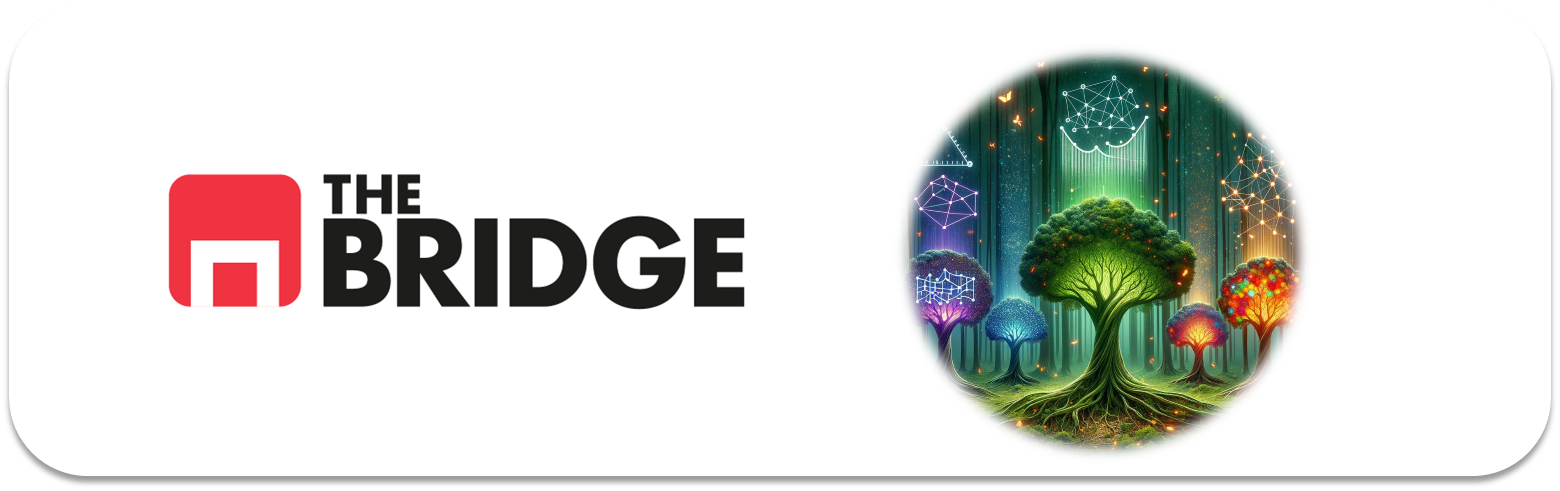

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# División y validación de datos
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV)

# Modelos Ensemble
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier)

# Métricas de evaluación
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score)

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [4]:
df = pd.read_csv(url, header=None, names=names)

df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Inspección inicial del dataset

Antes de comenzar con el modelado, revisamos la estructura general del dataset: número de registros y variables, tipos de datos, valores nulos y posibles registros duplicados.

In [5]:
print("Dimensiones del dataset:", df.shape)

print("\nInformación general:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Dimensiones del dataset: (768, 9)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Valores nulos por columna:
preg     0
plas     0
pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64

Registros duplicados:
0


## 2. Análisis descriptivo de las variables

Revisamos los principales estadísticos descriptivos de las variables numéricas para conocer su distribución, tangos de valores y deterctar posibles valores anómalos.

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
plas,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
pres,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
skin,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
test,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
mass,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
pedi,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
class,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 3. Revisión de valores cero en variables médicas

Aunque el dataset no presenta valores nulos (`NaN`), el análisis descriptivo muestra valores iguales a cero en algunas variables médicas.

Dado que un valor cero puede no ser válido para determinadas mediciones, revisamos su frecuencia antes de decidir si requieren algún tratamiento.

In [7]:
variables_medicas = ["plas", "pres", "skin", "test", "mass"]

ceros = pd.DataFrame({
    "Nº de ceros": (df[variables_medicas] == 0).sum(),
    "Porcentaje (%)": ((df[variables_medicas] == 0).mean() * 100).round(2)
})

ceros

,Nº de ceros,Porcentaje (%)
plas,5,0.65
pres,35,4.56
skin,227,29.56
test,374,48.70
mass,11,1.43


## 4. Distribución de la variable objetivo

Analizamos la distribución de la variable `class`, que indica si la paciente desarrolló diabetes (`1`) o no (`0`).

Esta revisión nos permitirá comprobar si existe desbalance entre las clases y tenerlo en cuenta tanto en la división de los datos como en la selección de las métricas de evaluación.

In [8]:
distribucion_clase = pd.DataFrame({
    "Cantidad": df["class"].value_counts(),
    "Porcentaje (%)": df["class"].value_counts(normalize=True).mul(100).round(2)
})

distribucion_clase

,Cantidad,Porcentaje (%)
class,,
0,500,65.1
1,268,34.9


### Conclusiones de la inspección inicial

- El dataset contiene 768 registros y 9 variables, todas de tipo numérico.
- No se han encontrado valores nulos ni registros duplicados.
- Se han detectado valores iguales a cero en algunas variables médicas (`plas`, `pres`, `skin`, `test` y `mass`) que podrían representar valores ausentes o mediciones no válidas.
- Destacan especialmente `skin` y `test`, con un 29.56 % y un 48.70 % de valores cero respectivamente, por lo que eliminar estos registros supondría una pérdida considerable de información.
- La variable objetivo presenta un desbalance moderado: el 65.1 % de los registros pertenece a la clase 0 y el 34.9 % a la clase 1. Por este motivo, se mantendrá esta proporción mediante una división estratificada de los datos y se tendrán en cuenta métricas adicionales a la accuracy para evaluar los modelos.

## 5. Separación de los datos en Train y Test

Separamos las variables predictoras (`X`) de la variable objetivo (`y`) y reservamos un 20 % de los datos como conjunto de test.

El conjunto de test se mantendrá apartado durante la comparación y optimización de los modelos y se utilizará únicamente para evaluar el modelo final seleccionado.

Se utiliza `stratify=y` para conservar aproximadamente la misma proporción de las clases en los conjuntos de entrenamiento y test.

In [9]:
X = df.drop(columns="class")
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


### 5.1 Comprobación de la distribución de clases en Train y Test

Comprobamos que la división estratificada haya mantenido una distribución similar de la variable objetivo en los conjuntos de Train y Test.

Esto es especialmente importante porque la variable objetivo presenta cierto desbalance entre las clases.

,Train (%),Test (%)
class,,
0,65.15,64.94
1,34.85,35.06


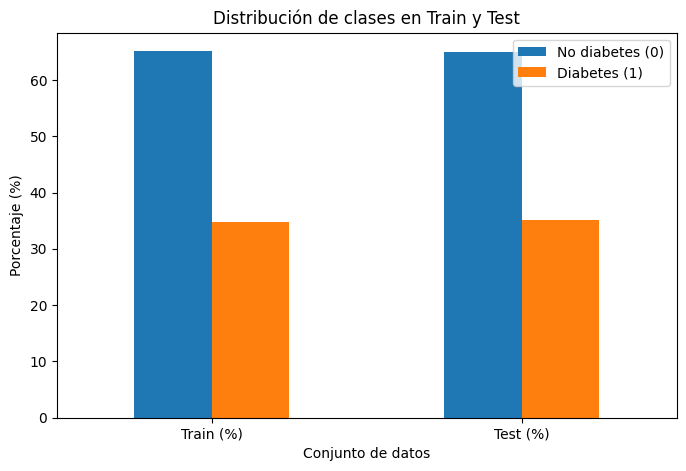

In [10]:
distribucion = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Test (%)": y_test.value_counts(normalize=True).sort_index().mul(100).round(2)
})

display(distribucion)

distribucion.T.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de clases en Train y Test")
plt.xlabel("Conjunto de datos")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(["No diabetes (0)", "Diabetes (1)"])
plt.show()

**Conclusión:** La distribución de la variable objetivo se mantiene prácticamente idéntica en los conjuntos de Train y Test, por lo que la división estratificada ha conservado correctamente la proporción original de las clases.

## 6. Análisis exploratorio del conjunto de entrenamiento

Una vez reservado el conjunto de test, realizamos un análisis visual utilizando únicamente los datos de entrenamiento.

El objetivo es conocer la distribución de las variables predictoras, identificar posibles asimetrías, valores extremos y patrones que puedan resultar relevantes antes del entrenamiento de los modelos.

### 6.1 Distribución de las variables predictoras

Representamos mediante histogramas la distribución de todas las variables predictoras del conjunto de entrenamiento.

Para facilitar su reutilización, agrupamos la generación de las gráficas en una función que permite visualizar conjuntamente todas las variables seleccionadas.

In [11]:
def plot_distributions(df, columns, bins=30):
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(
            data=df,
            x=col,
            bins=bins,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(f"Distribución de {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

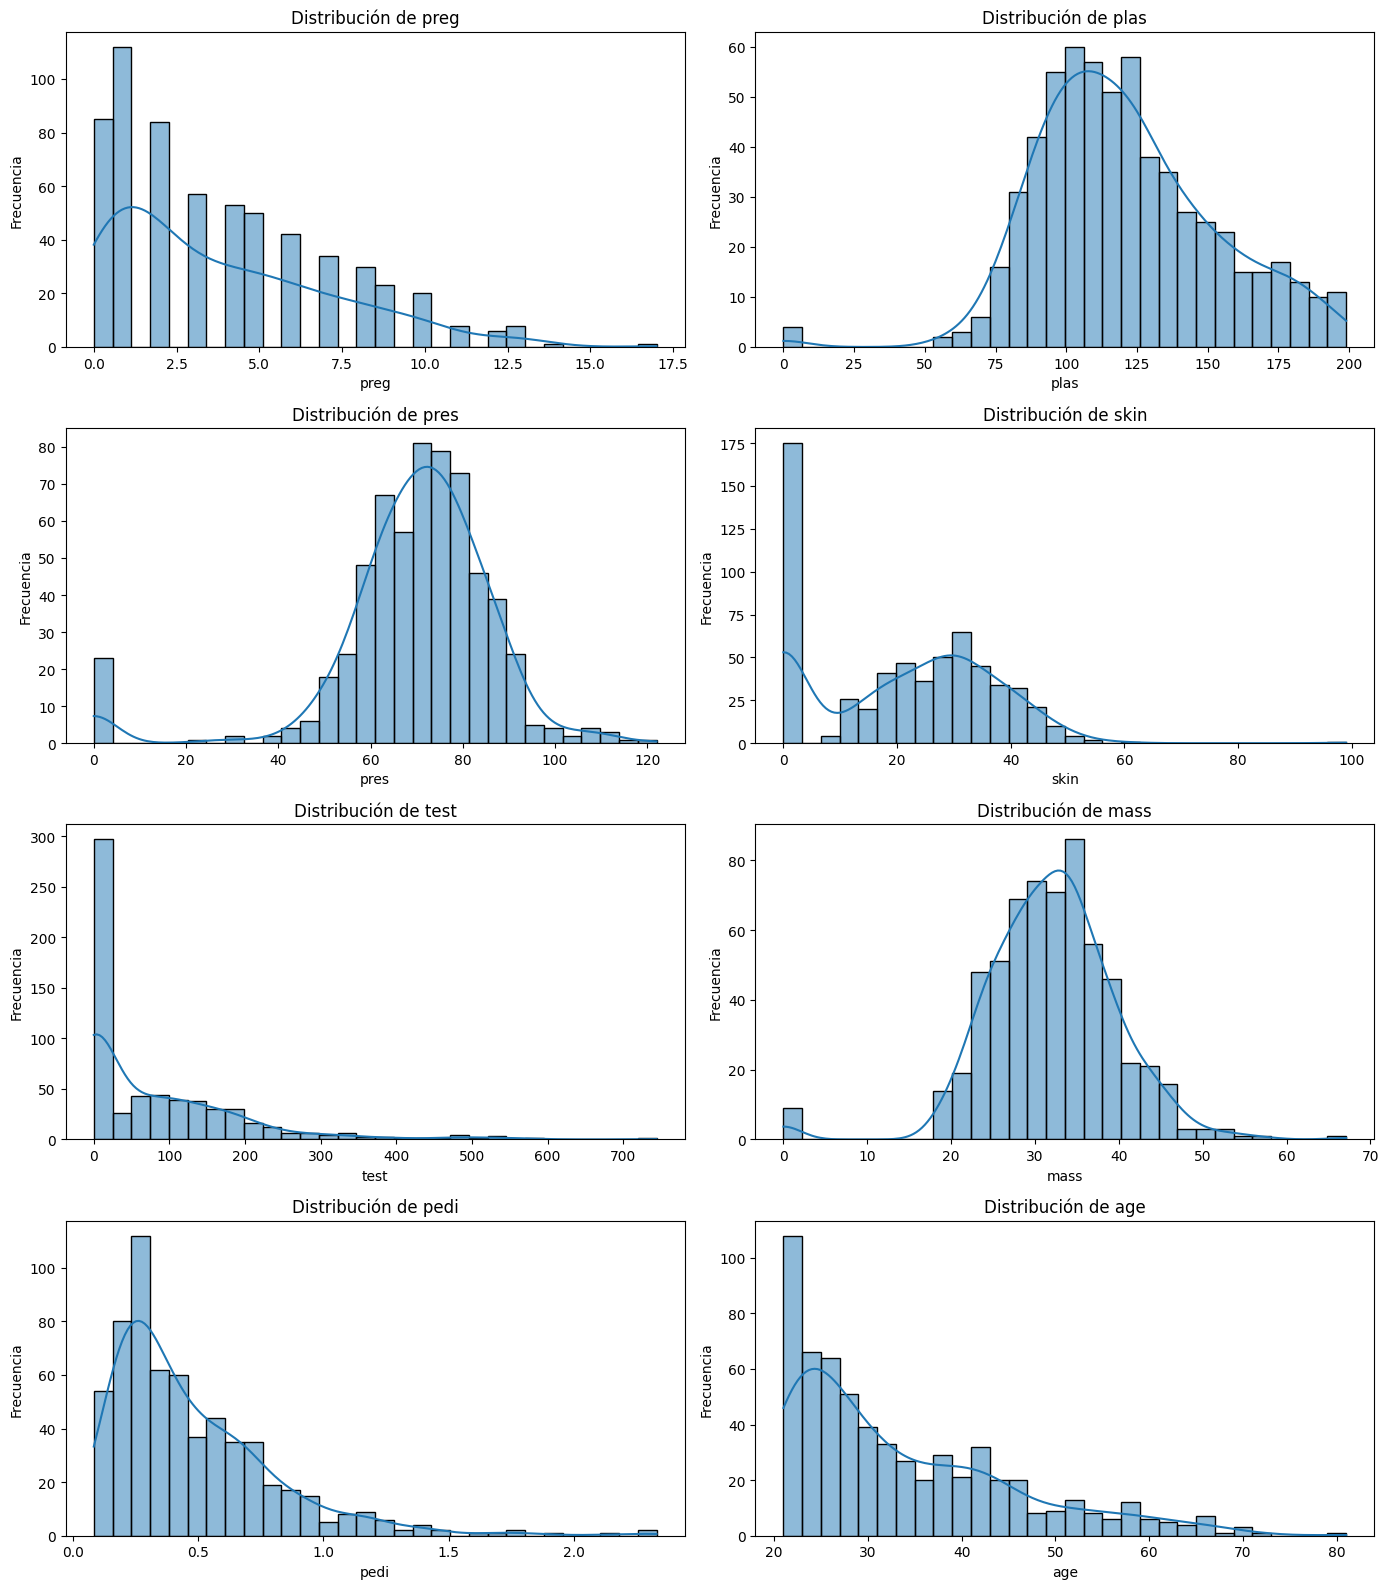

In [12]:
plot_distributions(X_train, X_train.columns)

**Conclusión:** Las variables presentan distribuciones heterogéneas y varias muestran asimetría positiva, especialmente `preg`, `test`, `pedi` y `age`. Además, los histogramas permiten observar claramente la concentración de valores cero en `plas`, `pres`, `skin`, `test` y `mass`, reforzando la hipótesis de que estos valores pueden representar mediciones ausentes o no válidas y deberán tratarse antes del entrenamiento de los modelos.

### 6.2 Relación de las variables predictoras con la diabetes

Analizamos la distribución de cada variable predictora en función de la variable objetivo.

Los diagramas de caja permiten comparar las pacientes que no desarrollaron diabetes (`0`) con aquellas que sí la desarrollaron (`1`), facilitando la identificación de diferencias entre ambos grupos y de posibles valores atípicos.

In [13]:
train_eda = X_train.copy()
train_eda["class"] = y_train

In [14]:
def plot_features_by_target(df, features, target):
    n_cols = 2
    n_rows = int(np.ceil(len(features) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows)
    )

    axes = axes.flatten()

    for i, feature in enumerate(features):
        sns.boxplot(
            data=df,
            x=target,
            y=feature,
            ax=axes[i]
        )

        axes[i].set_title(f"{feature} según {target}")
        axes[i].set_xlabel("Diabetes")
        axes[i].set_ylabel(feature)

    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

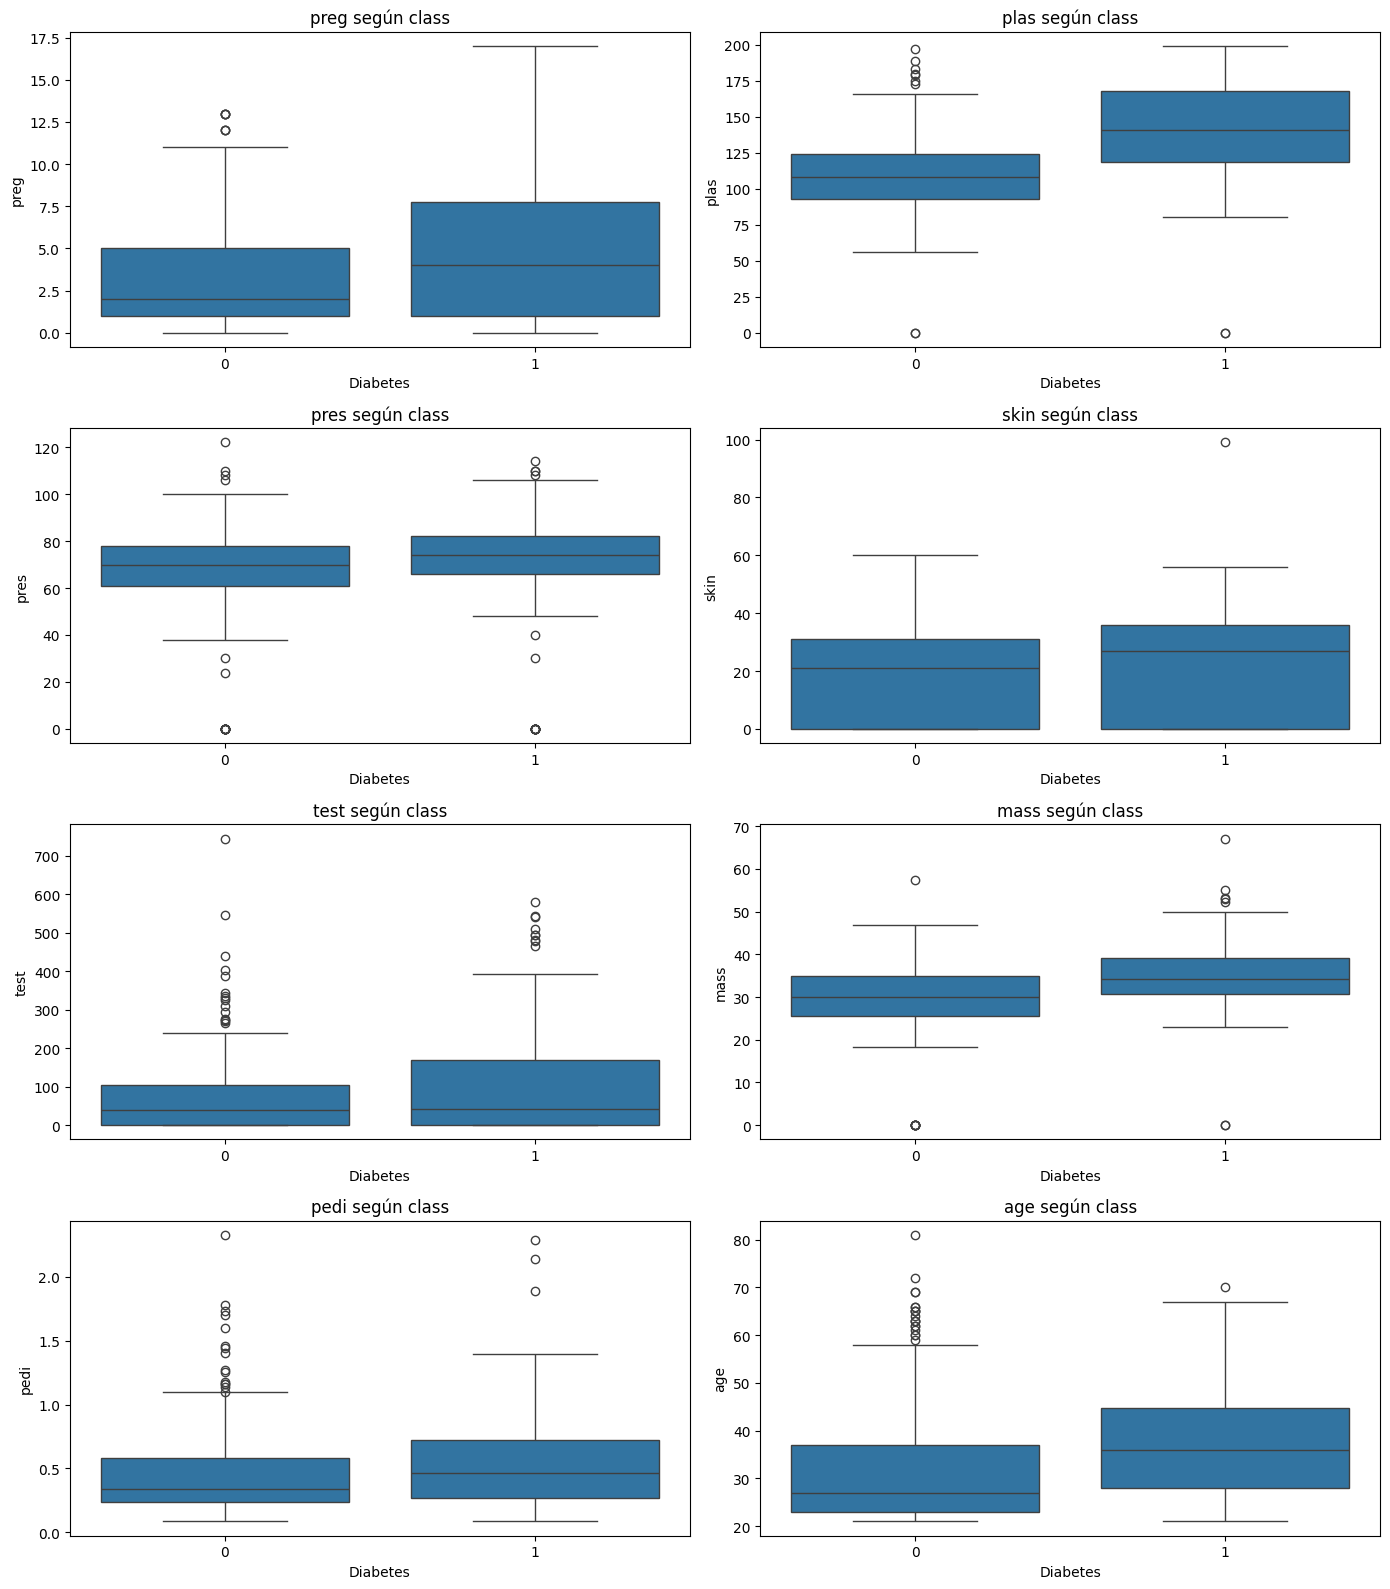

In [15]:
plot_features_by_target(
    train_eda,
    X_train.columns,
    "class"
)

**Conclusión:** Los diagramas de caja muestran diferencias entre las dos clases en varias variables. La concentración de glucosa (`plas`) presenta una separación especialmente clara, con valores generalmente superiores en las pacientes que desarrollaron diabetes.

También se observan valores más elevados de IMC (`mass`), edad (`age`), número de embarazos (`preg`) y función de pedigree (`pedi`) en la clase positiva. Por el contrario, la presión arterial (`pres`) presenta un mayor solapamiento entre ambos grupos.

Las variables `skin` y `test` están especialmente condicionadas por la elevada presencia de valores cero detectada anteriormente, por lo que su interpretación debe realizarse con precaución.

### 6.3 Análisis de correlaciones

Analizamos la correlación entre las variables numéricas del conjunto de entrenamiento mediante una matriz de correlaciones.

Este análisis permite identificar qué variables presentan una mayor asociación lineal con la variable objetivo y detectar posibles relaciones entre las propias variables predictoras.

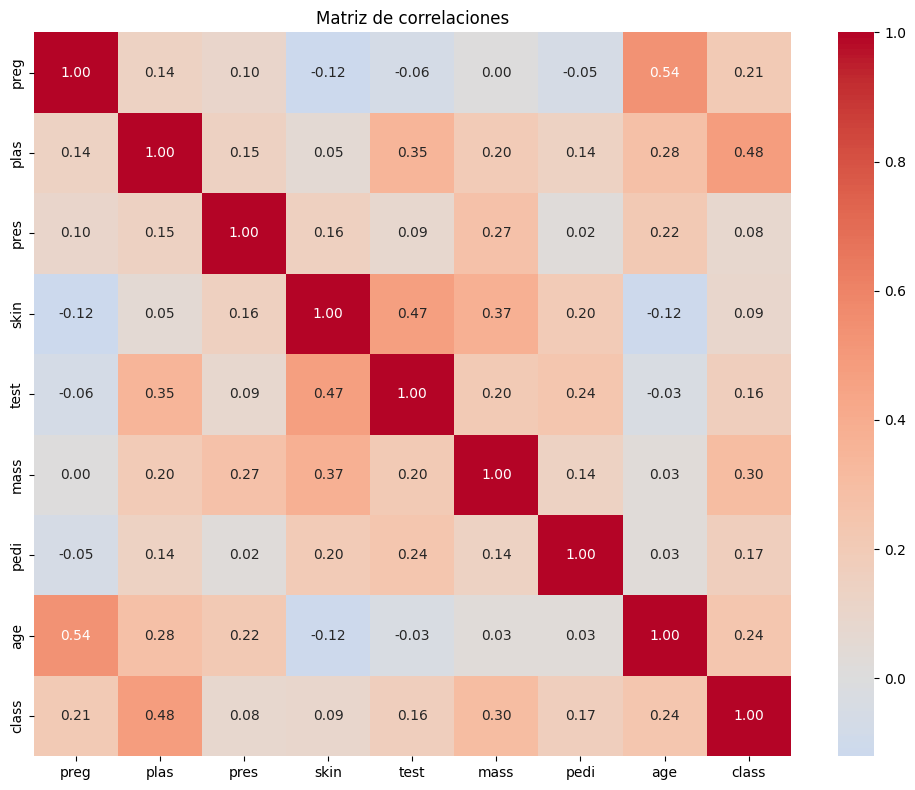

In [16]:
plt.figure(figsize=(10, 8))

corr = train_eda.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

**Conclusión:** El análisis de correlaciones confirma los patrones observados previamente. La concentración de glucosa (`plas`) presenta la mayor correlación positiva con la variable objetivo (`0.48`), seguida del índice de masa corporal (`mass`, `0.30`), la edad (`age`, `0.24`) y el número de embarazos (`preg`, `0.21`).

No se observan correlaciones excesivamente elevadas entre las variables predictoras, aunque destacan algunas relaciones moderadas, como la existente entre `preg` y `age` (`0.54`) y entre `skin` y `test` (`0.47`).

Estos resultados sugieren que variables como la glucosa y el IMC podrían tener un papel especialmente relevante en la predicción de diabetes, aunque la correlación por sí sola no determina la importancia que tendrán posteriormente en los modelos.

## 7. Preparación de los datos y tratamiento de valores cero

Durante el análisis exploratorio se detectaron valores iguales a cero en las variables `plas`, `pres`, `skin`, `test` y `mass`.

Dado que estos valores no representan mediciones válidas para estas variables, se interpretarán como valores ausentes. Para evitar eliminar una cantidad importante de registros, especialmente en `skin` y `test`, posteriormente se imputarán utilizando la mediana.

La imputación se integrará dentro del proceso de modelado para evitar fugas de información durante la validación cruzada.

In [17]:
variables_con_ceros = ["plas", "pres", "skin", "test", "mass"]

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean[variables_con_ceros] = (
    X_train_clean[variables_con_ceros].replace(0, np.nan)
)

X_test_clean[variables_con_ceros] = (
    X_test_clean[variables_con_ceros].replace(0, np.nan)
)

### 7.1 Comprobación de los valores ausentes

Comprobamos la cantidad y el porcentaje de valores ausentes presentes en el conjunto de entrenamiento después de convertir los ceros no válidos en `NaN`.

In [18]:
nulos_train = pd.DataFrame({
    "Nº de nulos": X_train_clean.isnull().sum(),
    "Porcentaje (%)": X_train_clean.isnull().mean().mul(100).round(2)
})

nulos_train

,Nº de nulos,Porcentaje (%)
preg,0,0.00
plas,4,0.65
pres,23,3.75
skin,175,28.50
test,290,47.23
mass,9,1.47
pedi,0,0.00
age,0,0.00


### 7.2 Preparación de la imputación mediante Pipeline

Para tratar los valores ausentes utilizaremos `SimpleImputer` con la estrategia de la mediana.

La imputación se integrará posteriormente dentro de un `Pipeline`, de forma que durante la validación cruzada la mediana se calcule únicamente con los datos utilizados para entrenar en cada partición, evitando así fugas de información.

## 8. Construcción de modelos Ensemble

Para resolver el problema de clasificación se compararán diferentes modelos basados en técnicas Ensemble.

Se utilizarán modelos pertenecientes tanto a métodos de **Bagging** como de **Boosting**, cumpliendo así con los requisitos del ejercicio.

Los modelos seleccionados inicialmente son:

- `RandomForestClassifier` como modelo basado en Bagging.
- `GradientBoostingClassifier` como modelo basado en Boosting.
- `AdaBoostClassifier` como segundo modelo de Boosting.

Todos los modelos se evaluarán utilizando únicamente el conjunto de entrenamiento mediante validación cruzada, manteniendo el conjunto de Test completamente reservado para la evaluación final.

### 8.1 Definición de los modelos base

Se crean tres modelos Ensemble con sus configuraciones iniciales.

Cada modelo se integra dentro de un `Pipeline` junto con la imputación mediante mediana, garantizando que el tratamiento de los valores ausentes forme parte del proceso de entrenamiento y validación.

In [19]:
modelos = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

pipelines = {
    nombre: Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", modelo)
    ])
    for nombre, modelo in modelos.items()
}

pipelines

{'Random Forest': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('model', RandomForestClassifier(random_state=42))]),
 'Gradient Boosting': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('model', GradientBoostingClassifier(random_state=42))]),
 'AdaBoost': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('model', AdaBoostClassifier(random_state=42))])}

### 8.2 Comparación de los modelos mediante validación cruzada

Para comparar los modelos sin utilizar el conjunto de Test, se empleará validación cruzada sobre los datos de entrenamiento.

Se evaluarán varias métricas de clasificación:

- **Accuracy:** proporción total de predicciones correctas.
- **Recall:** capacidad del modelo para identificar correctamente los casos positivos de diabetes.
- **F1-score:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad general del modelo para distinguir entre ambas clases.

Dado que el objetivo es detectar pacientes que desarrollarán diabetes y existe cierto desbalance entre las clases, no se utilizará únicamente la accuracy para seleccionar el mejor modelo.

In [20]:
resultados = []

for nombre, pipeline in pipelines.items():

    accuracy = cross_val_score(
        pipeline, X_train_clean, y_train,
        cv=5, scoring="accuracy"
    ).mean()

    recall = cross_val_score(
        pipeline, X_train_clean, y_train,
        cv=5, scoring="recall"
    ).mean()

    f1 = cross_val_score(
        pipeline, X_train_clean, y_train,
        cv=5, scoring="f1"
    ).mean()

    roc_auc = cross_val_score(
        pipeline, X_train_clean, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

resultados_df = pd.DataFrame(resultados).set_index("Modelo").round(3)

resultados_df

,Accuracy,Recall,F1,ROC-AUC
Modelo,,,,
Random Forest,0.769,0.584,0.638,0.823
Gradient Boosting,0.759,0.608,0.636,0.813
AdaBoost,0.769,0.575,0.633,0.826


### 8.3 Comparación visual del rendimiento de los modelos

Para facilitar la comparación entre los modelos Ensemble, representamos gráficamente las métricas obtenidas mediante validación cruzada.

La visualización permite identificar qué modelos destacan en cada métrica y comprobar si existe un modelo claramente superior al resto.

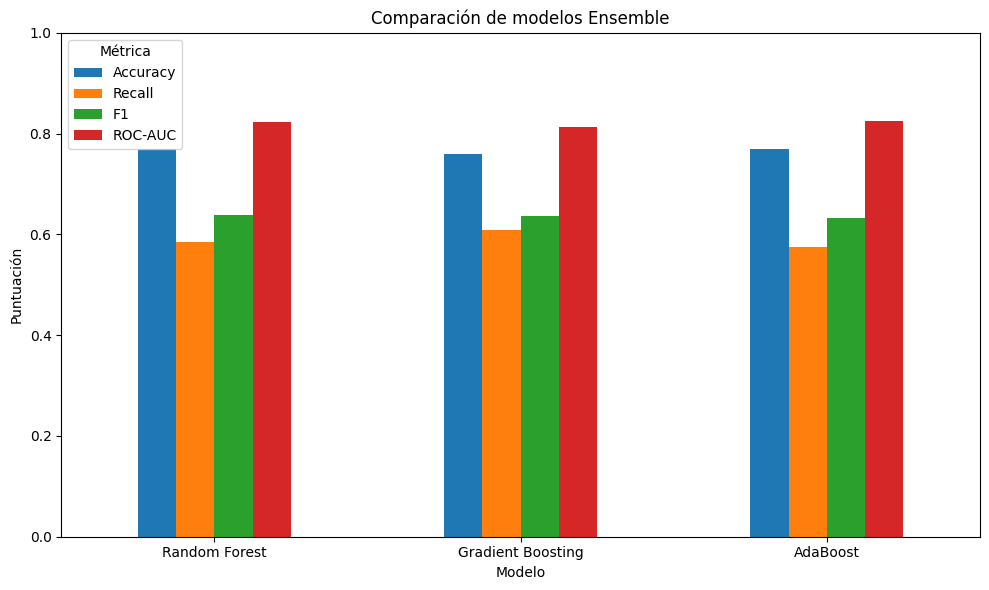

In [21]:
resultados_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de modelos Ensemble")
plt.xlabel("Modelo")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

### 8.4 Selección del modelo

Los tres modelos presentan resultados similares, aunque destacan en métricas diferentes. Random Forest obtiene el mayor F1-score (`0.638`), AdaBoost presenta el mayor ROC-AUC (`0.826`) y Gradient Boosting alcanza el mayor Recall (`0.608`).

Dado que el objetivo del problema es identificar pacientes que desarrollarán diabetes, se considera especialmente relevante reducir los falsos negativos, es decir, los casos de pacientes con diabetes que el modelo clasifica como negativas.

Por este motivo se selecciona **Gradient Boosting** para la fase de optimización. Aunque su Accuracy y ROC-AUC iniciales son ligeramente inferiores, presenta el mejor Recall y un F1-score prácticamente equivalente al mejor resultado obtenido.

A continuación, se optimizarán sus hiperparámetros utilizando únicamente el conjunto de entrenamiento, manteniendo el conjunto de Test reservado para la evaluación final.

## 9. Optimización de hiperparámetros de Gradient Boosting

Una vez seleccionado Gradient Boosting como el modelo más adecuado, se procede a optimizar sus hiperparámetros utilizando únicamente el conjunto de entrenamiento.

La búsqueda se realizará mediante validación cruzada, manteniendo el conjunto de Test completamente reservado para la evaluación final.

Se explorarán algunos de los principales hiperparámetros del modelo:

- `n_estimators`: número de árboles construidos de forma secuencial.
- `learning_rate`: contribución de cada árbol al modelo final.
- `max_depth`: profundidad máxima de los árboles individuales.
- `min_samples_split`: número mínimo de muestras necesarias para dividir un nodo.
- `min_samples_leaf`: número mínimo de muestras que debe contener una hoja.

### 9.1 Definición del espacio de búsqueda

Se define el conjunto de valores que se evaluarán para los principales hiperparámetros de Gradient Boosting durante el proceso de optimización.

In [22]:
param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [1, 2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

param_grid

{'model__n_estimators': [50, 100, 150, 200],
 'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
 'model__max_depth': [1, 2, 3, 4],
 'model__min_samples_split': [2, 5, 10],
 'model__min_samples_leaf': [1, 2, 4]}

### 9.2 Búsqueda de los mejores hiperparámetros

Para optimizar Gradient Boosting se utilizará `GridSearchCV`, que probará las diferentes combinaciones de hiperparámetros definidas anteriormente mediante validación cruzada.

Como métrica de optimización se utilizará **Recall**, ya que en este problema resulta especialmente importante identificar correctamente a las pacientes que desarrollarán diabetes y reducir el número de falsos negativos.

La búsqueda se realizará exclusivamente sobre el conjunto de entrenamiento.

In [23]:
gradient_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=gradient_pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_clean, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the c

In [24]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor Recall medio en validación cruzada:")
print(round(grid_search.best_score_, 3))

Mejores hiperparámetros:
{'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Mejor Recall medio en validación cruzada:
0.65


### 9.3 Comparación del modelo base y el modelo optimizado

La optimización mediante `GridSearchCV` obtuvo un Recall medio de `0.650`, superior al `0.608` obtenido inicialmente por Gradient Boosting.

Sin embargo, dado que la búsqueda se realizó optimizando específicamente el Recall, es necesario comprobar cómo afecta esta configuración al resto de métricas antes de considerar definitivamente mejor al modelo optimizado.

Por ello, se comparará mediante validación cruzada el Gradient Boosting base con el modelo optimizado, utilizando nuevamente únicamente el conjunto de entrenamiento.

In [25]:
gradient_optimizado = grid_search.best_estimator_

gradient_optimizado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [26]:
modelos_gradient = {
    "Gradient Boosting Base": pipelines["Gradient Boosting"],
    "Gradient Boosting Optimizado": gradient_optimizado
}

resultados_gradient = []

for nombre, modelo in modelos_gradient.items():

    accuracy = cross_val_score(
        modelo, X_train_clean, y_train,
        cv=5, scoring="accuracy"
    ).mean()

    recall = cross_val_score(
        modelo, X_train_clean, y_train,
        cv=5, scoring="recall"
    ).mean()

    f1 = cross_val_score(
        modelo, X_train_clean, y_train,
        cv=5, scoring="f1"
    ).mean()

    roc_auc = cross_val_score(
        modelo, X_train_clean, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    resultados_gradient.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

comparacion_gradient = (
    pd.DataFrame(resultados_gradient)
    .set_index("Modelo")
    .round(3)
)

comparacion_gradient

,Accuracy,Recall,F1,ROC-AUC
Modelo,,,,
Gradient Boosting Base,0.759,0.608,0.636,0.813
Gradient Boosting Optimizado,0.757,0.650,0.650,0.793


### 9.4 Comparación visual antes y después de la optimización

Representamos las métricas obtenidas mediante validación cruzada por el modelo Gradient Boosting base y su versión optimizada.

Esta comparación permite observar el efecto de la optimización sobre el rendimiento global del modelo y comprobar si la mejora del Recall supone una pérdida significativa en el resto de métricas.

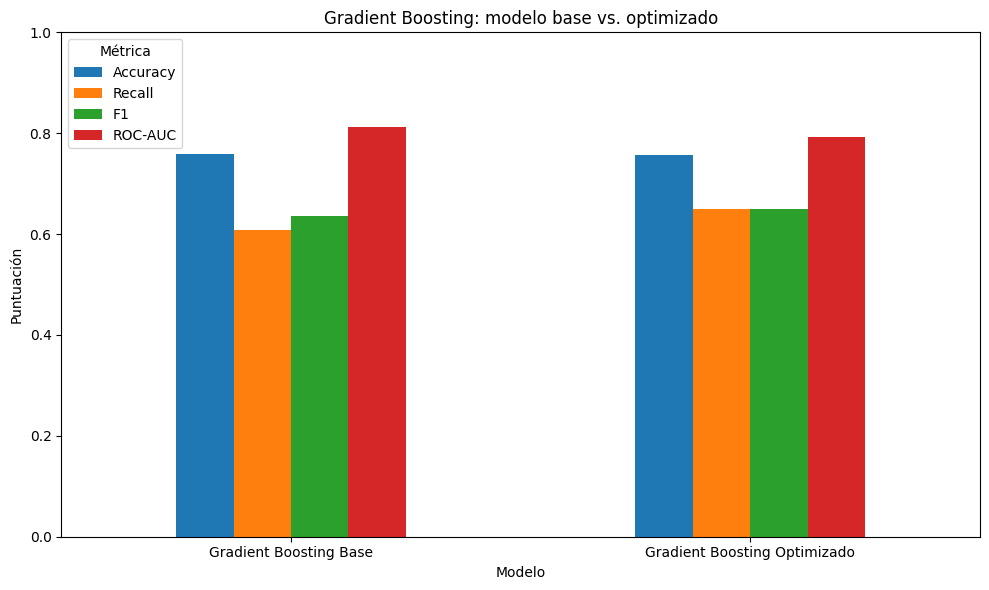

In [27]:
comparacion_gradient.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gradient Boosting: modelo base vs. optimizado")
plt.xlabel("Modelo")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

### 9.5 Conclusiones de la optimización

La optimización de hiperparámetros modifica el comportamiento del modelo de forma coherente con la métrica utilizada durante la búsqueda.

El **Recall aumenta de 0.608 a 0.650**, lo que supone una mejora en la capacidad del modelo para identificar correctamente a las pacientes que desarrollarán diabetes. Además, el **F1-score mejora de 0.636 a 0.650**, indicando un mejor equilibrio entre Precision y Recall.

Por otro lado, la Accuracy se mantiene prácticamente estable, pasando de 0.759 a 0.757, mientras que el ROC-AUC disminuye de 0.813 a 0.793.

Dado que la optimización se planteó priorizando la detección de casos positivos y la mejora del Recall se consigue sin una pérdida relevante de Accuracy y con una mejora adicional del F1-score, se selecciona el **Gradient Boosting optimizado** como modelo final.

El conjunto de Test, reservado desde el inicio del análisis, se utilizará a continuación para evaluar por primera vez el rendimiento del modelo seleccionado sobre datos no utilizados durante la comparación ni la optimización.

## 10. Evaluación final sobre el conjunto de Test

Una vez seleccionado y optimizado el modelo utilizando exclusivamente los datos de entrenamiento, se evalúa su rendimiento sobre el conjunto de Test reservado al inicio del análisis.

Esta evaluación permite comprobar la capacidad de generalización del modelo sobre datos que no han participado ni en la comparación de modelos ni en la optimización de hiperparámetros.

Se analizarán diferentes métricas de clasificación, prestando especial atención al Recall de la clase positiva.

### 10.1 Predicciones sobre el conjunto de Test

Utilizamos el modelo Gradient Boosting optimizado para realizar predicciones sobre el conjunto de Test reservado desde el inicio del análisis.

Además de obtener las clases predichas, calculamos las probabilidades asociadas a la clase positiva (`1`), que posteriormente utilizaremos para evaluar métricas como ROC-AUC.

In [28]:
y_pred = gradient_optimizado.predict(X_test_clean)
y_proba = gradient_optimizado.predict_proba(X_test_clean)[:, 1]

### 10.2 Informe de clasificación

Evaluamos el rendimiento del modelo final mediante las principales métricas de clasificación sobre el conjunto de Test.

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



### 10.3 Matriz de confusión

Para analizar con mayor detalle los aciertos y errores del modelo final, representamos la matriz de confusión sobre el conjunto de Test.

Esta visualización permite distinguir entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, siendo estos últimos especialmente relevantes en el contexto del problema.

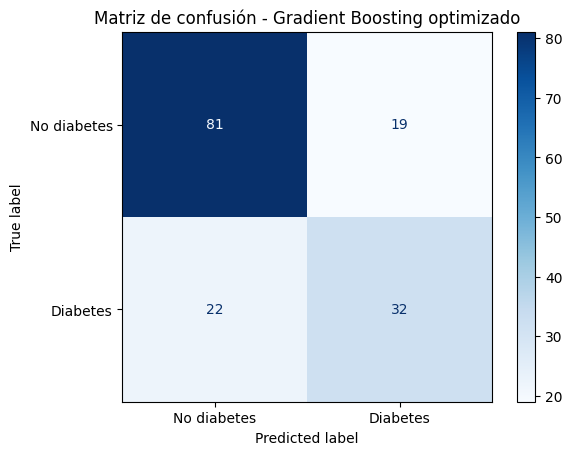

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues"
)

plt.title("Matriz de confusión - Gradient Boosting optimizado")
plt.show()

**Interpretación:** La matriz de confusión muestra que el modelo clasifica correctamente 81 pacientes sin diabetes y 32 pacientes con diabetes.

Por otro lado, se producen 19 falsos positivos y 22 falsos negativos. Estos últimos representan pacientes que realmente pertenecen a la clase positiva pero que el modelo no logra identificar, lo que explica el Recall de `0.59` obtenido para la clase diabetes.

Aunque el modelo consigue detectar una parte importante de los casos positivos, los falsos negativos continúan siendo un aspecto relevante a considerar en la evaluación final.

### 10.4 ROC-AUC y curva ROC

Para completar la evaluación del modelo final, calculamos el ROC-AUC utilizando las probabilidades predichas para la clase positiva.

Esta métrica permite evaluar la capacidad del modelo para distinguir entre pacientes con y sin diabetes considerando diferentes umbrales de clasificación.

Además, representamos la curva ROC para visualizar la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos.

In [31]:
roc_auc_test = roc_auc_score(y_test, y_proba)

print("ROC-AUC en Test:", round(roc_auc_test, 3))

ROC-AUC en Test: 0.808


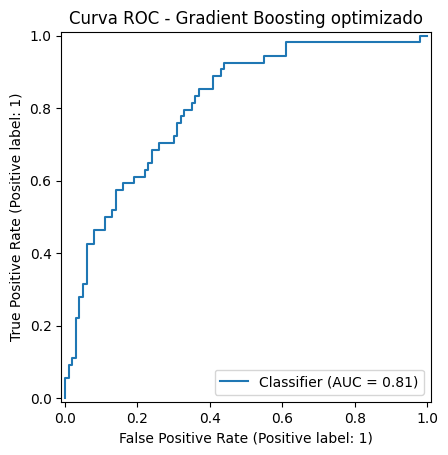

In [32]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("Curva ROC - Gradient Boosting optimizado")
plt.show()

**Interpretación:** El modelo obtiene un ROC-AUC de `0.808` sobre el conjunto de Test, lo que indica una buena capacidad para diferenciar entre pacientes con y sin diabetes.

Este resultado es similar al obtenido durante la validación cruzada (`0.793`), lo que sugiere que la capacidad de discriminación del modelo se mantiene razonablemente estable sobre datos no utilizados durante el entrenamiento.

Sin embargo, el Recall de la clase positiva obtenido en Test (`0.59`) muestra que todavía existe margen de mejora en la detección de pacientes que desarrollarán diabetes.

### 10.5 Resumen de resultados en Test

Para facilitar la interpretación del rendimiento final del modelo, reunimos en una tabla las principales métricas obtenidas sobre el conjunto de Test.

Se incluyen las métricas correspondientes a la clase positiva (`1 = Diabetes`) junto con la Accuracy global y el ROC-AUC.

In [34]:
resumen_test = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Resultado": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_test
    ]
})

resumen_test["Resultado"] = resumen_test["Resultado"].round(3)

resumen_test

,Métrica,Resultado
0,Accuracy,0.734
1,Precision,0.627
2,Recall,0.593
3,F1-score,0.610
4,ROC-AUC,0.808


### 10.6 Visualización de las métricas finales

Para complementar el resumen numérico, representamos gráficamente las principales métricas obtenidas por el modelo Gradient Boosting optimizado sobre el conjunto de Test.

Esta visualización permite comparar de forma directa el rendimiento alcanzado en cada una de las métricas evaluadas.

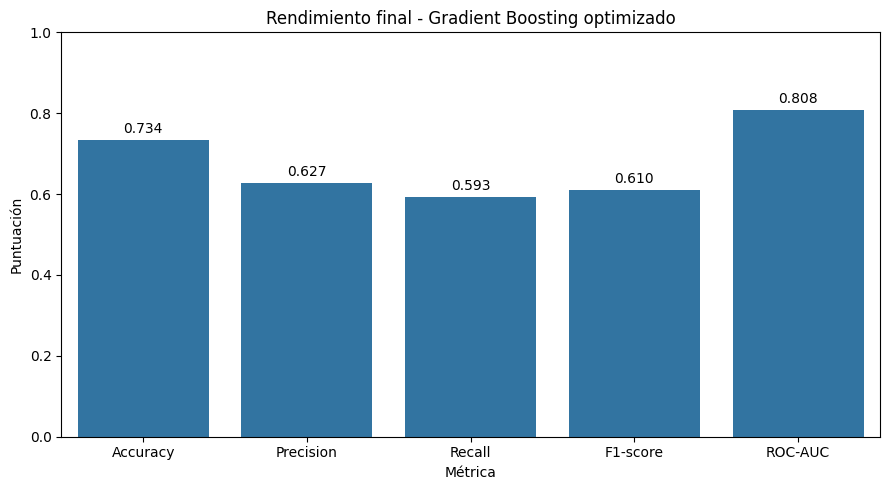

In [35]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumen_test,
    x="Métrica",
    y="Resultado"
)

plt.title("Rendimiento final - Gradient Boosting optimizado")
plt.xlabel("Métrica")
plt.ylabel("Puntuación")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

## 11. Conclusiones finales

El objetivo de este ejercicio era construir un modelo capaz de predecir si una mujer de ascendencia india Pima, de al menos 21 años, desarrollará diabetes dentro de los siguientes cinco años a partir de diferentes variables médicas.

Para ello se compararon tres modelos Ensemble: **Random Forest**, **Gradient Boosting** y **AdaBoost**. La comparación se realizó exclusivamente sobre el conjunto de entrenamiento mediante validación cruzada, manteniendo el conjunto de Test reservado hasta la evaluación final.

Los tres modelos obtuvieron resultados similares, aunque Gradient Boosting presentó el mayor Recall (`0.608`). Dado que en este problema resulta especialmente relevante identificar correctamente a las pacientes que desarrollarán diabetes, este modelo fue seleccionado para la fase de optimización.

Mediante `GridSearchCV`, utilizando Recall como métrica objetivo, se consiguió aumentar esta métrica hasta `0.650` en validación cruzada, junto con una mejora del F1-score de `0.636` a `0.650`.

Finalmente, el Gradient Boosting optimizado se evaluó sobre el conjunto de Test, obteniendo:

- **Accuracy:** `0.734`
- **Precision:** `0.627`
- **Recall:** `0.593`
- **F1-score:** `0.610`
- **ROC-AUC:** `0.808`

La matriz de confusión mostró que, de las 54 pacientes del conjunto de Test que desarrollaron diabetes, el modelo identificó correctamente a 32, mientras que 22 fueron clasificadas incorrectamente como negativas.

Por tanto, **sí es posible utilizar las variables médicas disponibles para construir un modelo con capacidad predictiva para identificar el riesgo de desarrollar diabetes en esta población**, como refleja especialmente el ROC-AUC de `0.808`.

Sin embargo, los resultados también muestran que la predicción está lejos de ser perfecta. El Recall de `0.593` implica que el modelo no identifica una parte relevante de las pacientes que realmente desarrollarán diabetes. Por este motivo, los resultados deben interpretarse como una herramienta predictiva con capacidad para diferenciar entre pacientes con distinto riesgo, pero con margen de mejora en la detección de casos positivos.

En conclusión, **Gradient Boosting permite aproximarnos al objetivo planteado y demuestra que existe información predictiva en las variables médicas disponibles**, aunque sería necesario mejorar especialmente la sensibilidad del modelo antes de considerar su utilización en un contexto donde los falsos negativos tengan consecuencias importantes.